Using device: cuda


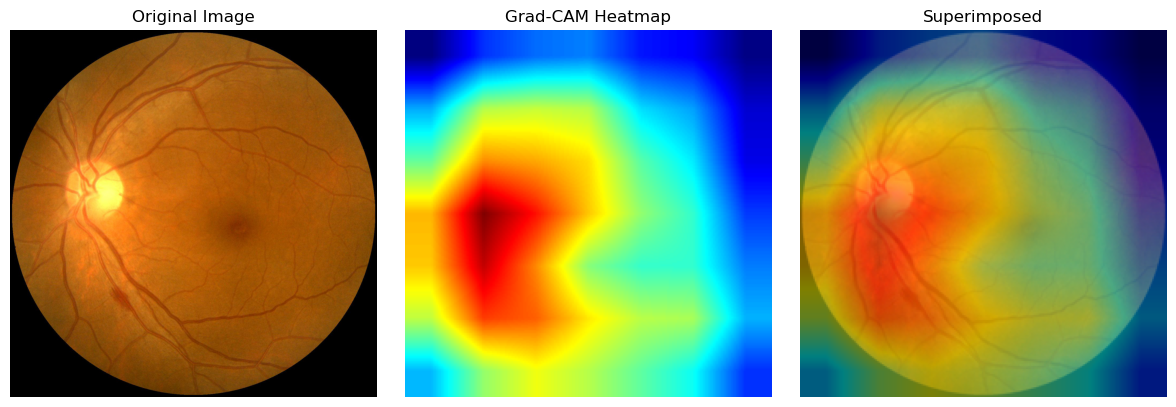

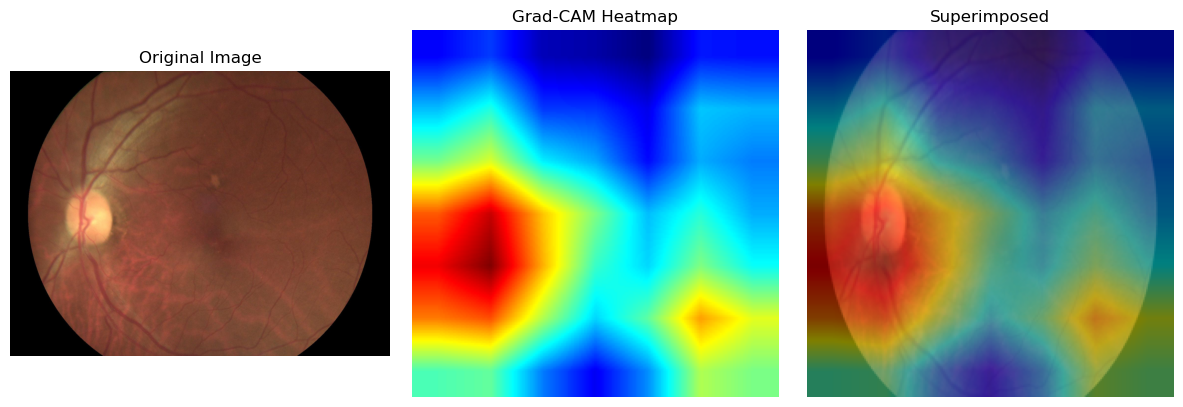

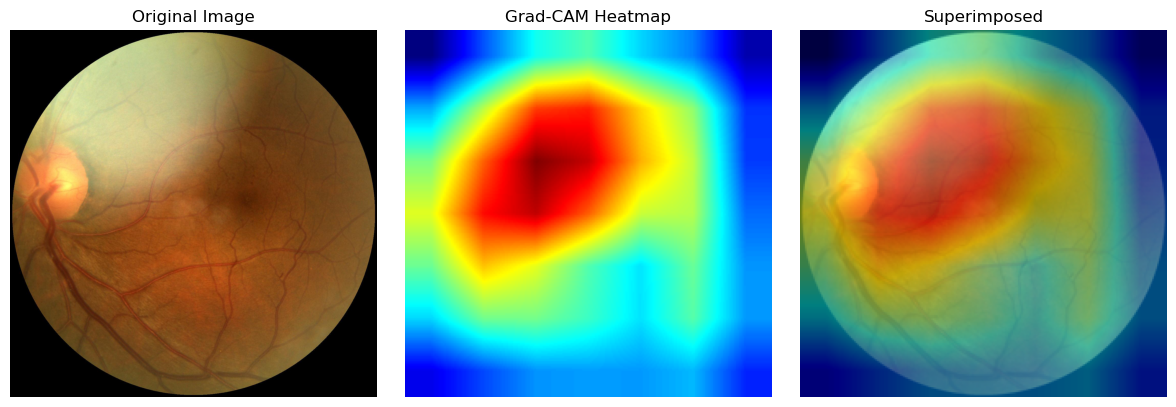

In [ ]:
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision import transforms

# ===========================
# 0️⃣ Device
# ===========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===========================
# 1️⃣ Load RetinaViT-AD Model
# ===========================
# Example RetinaViT-AD model (update architecture as per your training)
class RetinaViT_AD(nn.Module):
    def __init__(self, num_classes=5):  # update num_classes
        super().__init__()
        # Example placeholder architecture
        self.conv1 = nn.Conv2d(3,64,3,padding=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(64,128,3,padding=1)
        self.pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(128,num_classes)
        self.feature_map = None

    def forward(self,x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        self.feature_map = x   # last conv feature for Grad-CAM
        x = self.pool(x)
        x = torch.flatten(x,1)
        x = self.fc(x)
        return x

# Path to your pretrained RetinaViT-AD model
model_path = r"D:\Models\RetinaViT_AD\best_model.pth"
NUM_CLASSES = 5  # adjust according to your dataset

model = RetinaViT_AD(NUM_CLASSES).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# ===========================
# 2️⃣ Images to evaluate
# ===========================
image_paths = [
    r"D:\Dataset\Ocular Disease Recognition\ODIR-5K\ODIR-5K\Testing Images\1063_left.jpg",
    r"D:\Dataset\Ocular Disease Recognition\ODIR-5K\ODIR-5K\Testing Images\1381_left.jpg"
]

# ===========================
# 3️⃣ Transform
# ===========================
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# ===========================
# 4️⃣ Grad-CAM Function
# ===========================
def generate_gradcam(model, img_tensor, target_class=None):
    # Forward pass
    output = model(img_tensor)
    if target_class is None:
        target_class = output.argmax(dim=1).item()

    # Backward pass
    model.zero_grad()
    one_hot = torch.zeros_like(output)
    one_hot[0, target_class] = 1
    output.backward(gradient=one_hot)

    features = model.feature_map.detach()
    gradients = model.feature_map.grad
    if gradients is None:
        # enable gradient for feature map
        features.requires_grad_()
        output.backward(gradient=one_hot)
        gradients = features.grad

    # Grad-CAM computation
    pooled_grad = torch.mean(gradients, dim=(2,3), keepdim=True)
    cam = torch.sum(pooled_grad * features, dim=1).squeeze().cpu().numpy()
    cam = np.maximum(cam,0)
    cam = cv2.resize(cam,(224,224))
    cam = cam - np.min(cam)
    cam = cam / (np.max(cam)+1e-8)
    return cam, target_class


for img_path in image_paths:
    img_pil = Image.open(img_path).convert('RGB')
    img_tensor = transform(img_pil).unsqueeze(0).to(device)

    cam, pred_class = generate_gradcam(model, img_tensor)

    heatmap = cv2.applyColorMap(np.uint8(255*cam), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    superimposed = np.array(img_pil.resize((224,224)))*0.5 + heatmap*0.5
    superimposed = superimposed.astype(np.uint8)

    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(img_pil)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(heatmap)
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(superimposed)
    plt.title("Superimposed")
    plt.axis('off')

    plt.tight_layout()
    plt.show()